# Life Cycle of Machine Learnin Project
1. Understand the Problem Statement
2. Data Checks to Perform
3. Exploratory Data Analysis
4. Data Pre-Processing
5. Model Training
6. Choose Best Model

**1. Understand the Problem Statemente**

Predicting the price of cars based on a wide range of attributes and features. Using a dataset containing car details such as safety ratings, dimensions, engine specifications, and more, we aim to develop a machine learning model that accurately estimates the price of different car models.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv('./dataset/CarPrice_Assignment.csv')

**2. Data Checks to Perform**

In [5]:
# Check Missing Values, duplicate, data types, unique values, statistics, various categories

df.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.dtypes

car_ID                int64
symboling             int64
CarName              object
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber       object
enginesize            int64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
dtype: object

In [8]:
df.nunique()

car_ID              205
symboling             6
CarName             147
fueltype              2
aspiration            2
doornumber            2
carbody               5
drivewheel            3
enginelocation        2
wheelbase            53
carlength            75
carwidth             44
carheight            49
curbweight          171
enginetype            7
cylindernumber        7
enginesize           44
fuelsystem            8
boreratio            38
stroke               37
compressionratio     32
horsepower           59
peakrpm              23
citympg              29
highwaympg           30
price               189
dtype: int64

In [9]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [10]:
categorical_columns = ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']

for col in categorical_columns:
    print(f"Category in {col} is: {df[col].unique()}")

Category in fueltype is: ['gas' 'diesel']
Category in aspiration is: ['std' 'turbo']
Category in doornumber is: ['two' 'four']
Category in carbody is: ['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']
Category in drivewheel is: ['rwd' 'fwd' '4wd']
Category in enginelocation is: ['front' 'rear']
Category in enginetype is: ['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf' 'dohcv']
Category in cylindernumber is: ['four' 'six' 'five' 'three' 'twelve' 'two' 'eight']
Category in fuelsystem is: ['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi']


**3. EDA (Exploratory Data Analysis)**

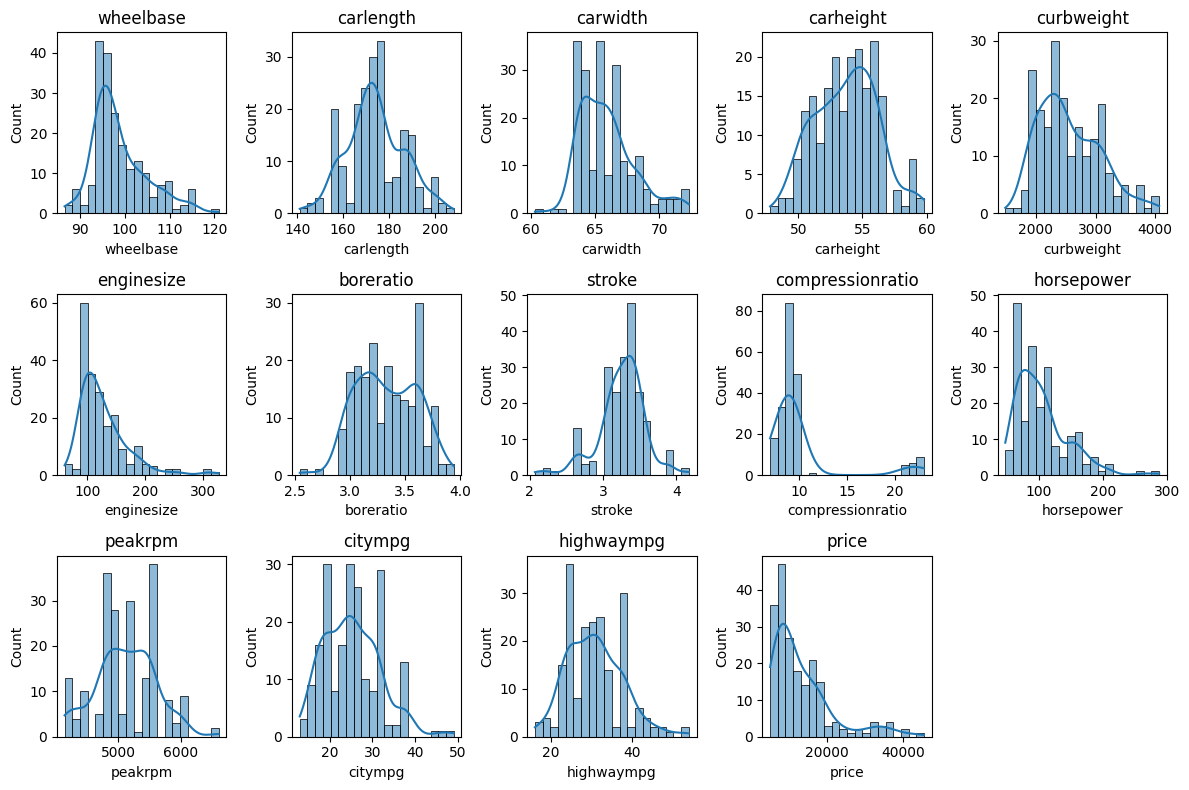

In [11]:
numerical_features = ['wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio',
                        'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']

plt.figure(figsize=(12, 8))
for feature in numerical_features:
    plt.subplot(3, 5, numerical_features.index(feature) + 1)
    sns.histplot(data=df[feature], bins=20, kde=True)
    plt.title(feature)
plt.tight_layout()
plt.show()

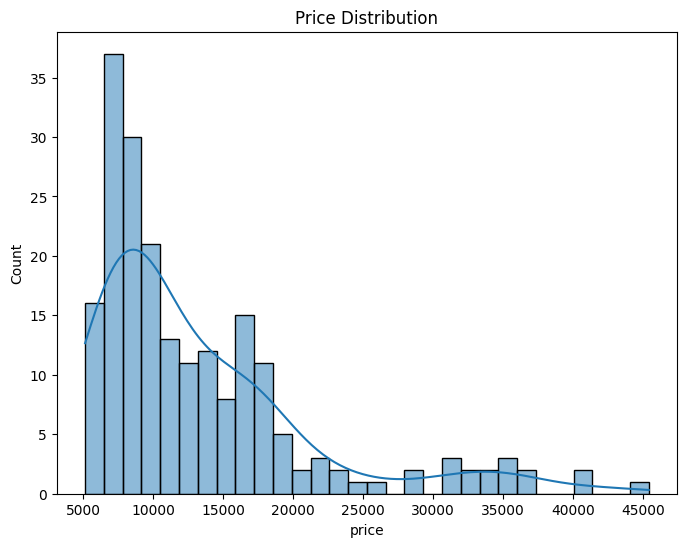

In [12]:
#Price Analysis
plt.figure(figsize=(8,6))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Price Distribution')
plt.show()

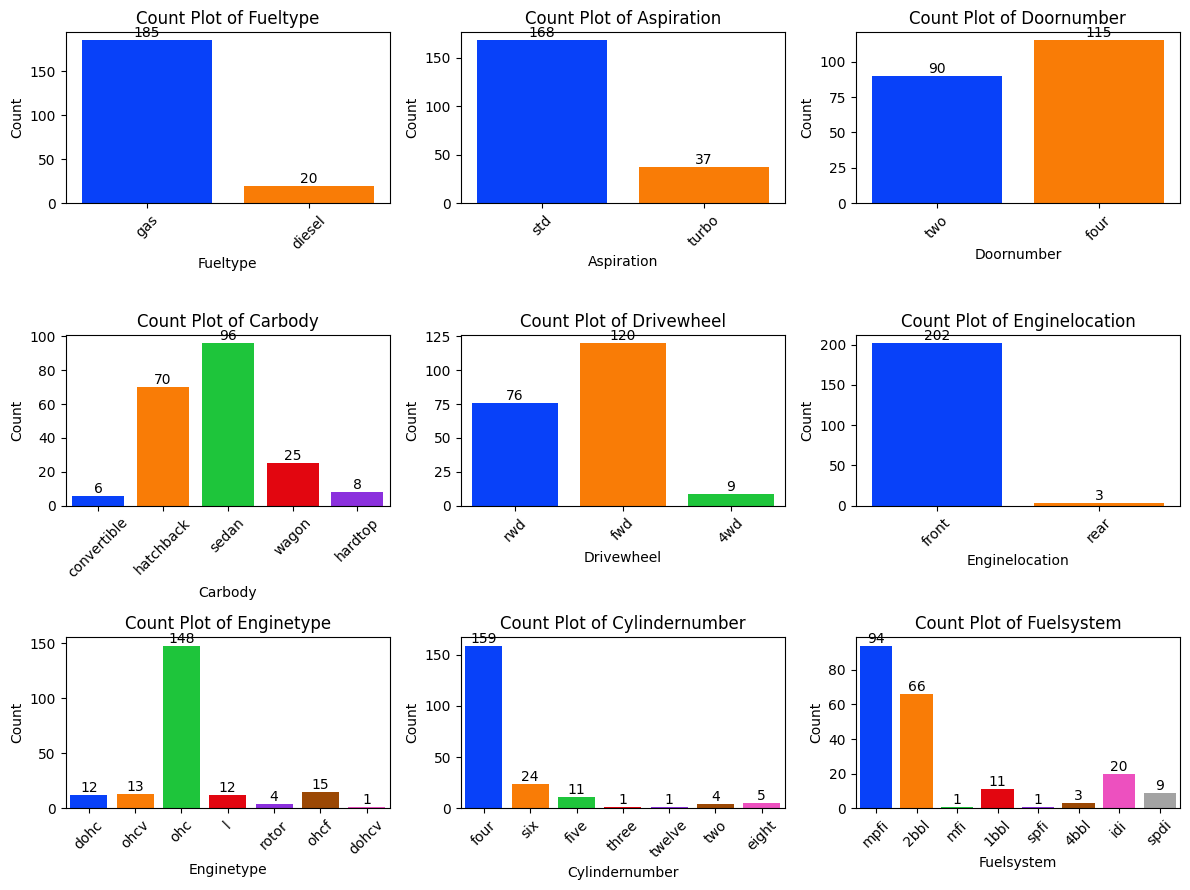

In [13]:
categorical_columns = df.select_dtypes(include=['object']).columns.drop('CarName', errors='ignore')  # Exclude 'CarName' if it's not needed

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 9))
axes = axes.ravel() # Flatten the 2D array of axes

for i, col in enumerate(categorical_columns):
    sns.countplot(x=df[col], data=df, palette='bright', ax=axes[i], saturation=0.95)
    for container in axes[i].containers:
        axes[i].bar_label(container, color='black', size=10)
    axes[i].set_title(f'Count Plot of {col.capitalize()}')
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

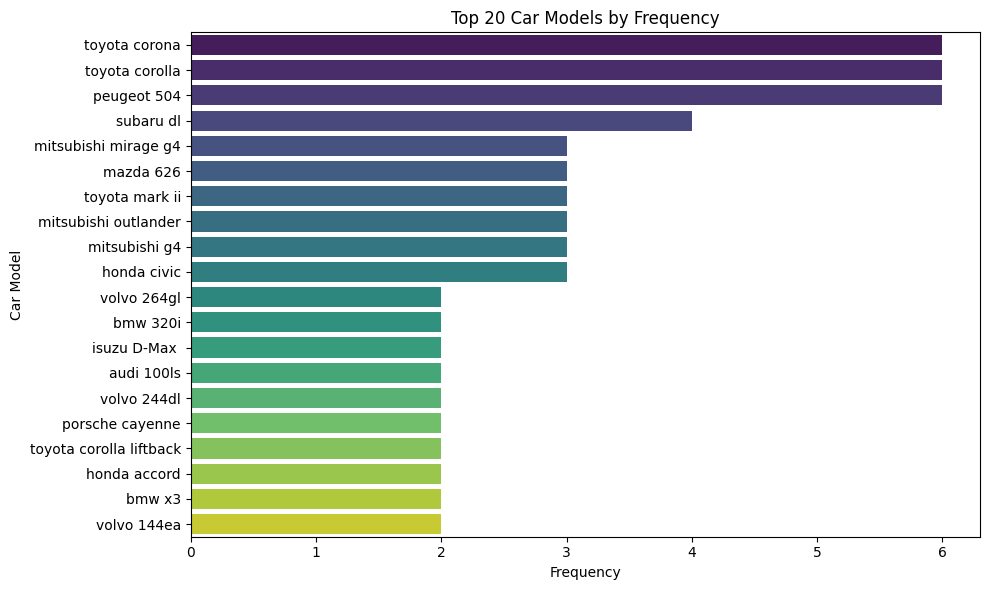

In [15]:
n = 20 #Number of top car models to plot
top_cars_models = df['CarName'].value_counts().head(n)

plt.figure(figsize=(10,6))
sns.barplot(x=top_cars_models.values, y=top_cars_models.index, palette='viridis')
plt.title(f'Top {n} Car Models by Frequency')
plt.xlabel('Frequency')
plt.ylabel('Car Model')
plt.tight_layout()
plt.show()

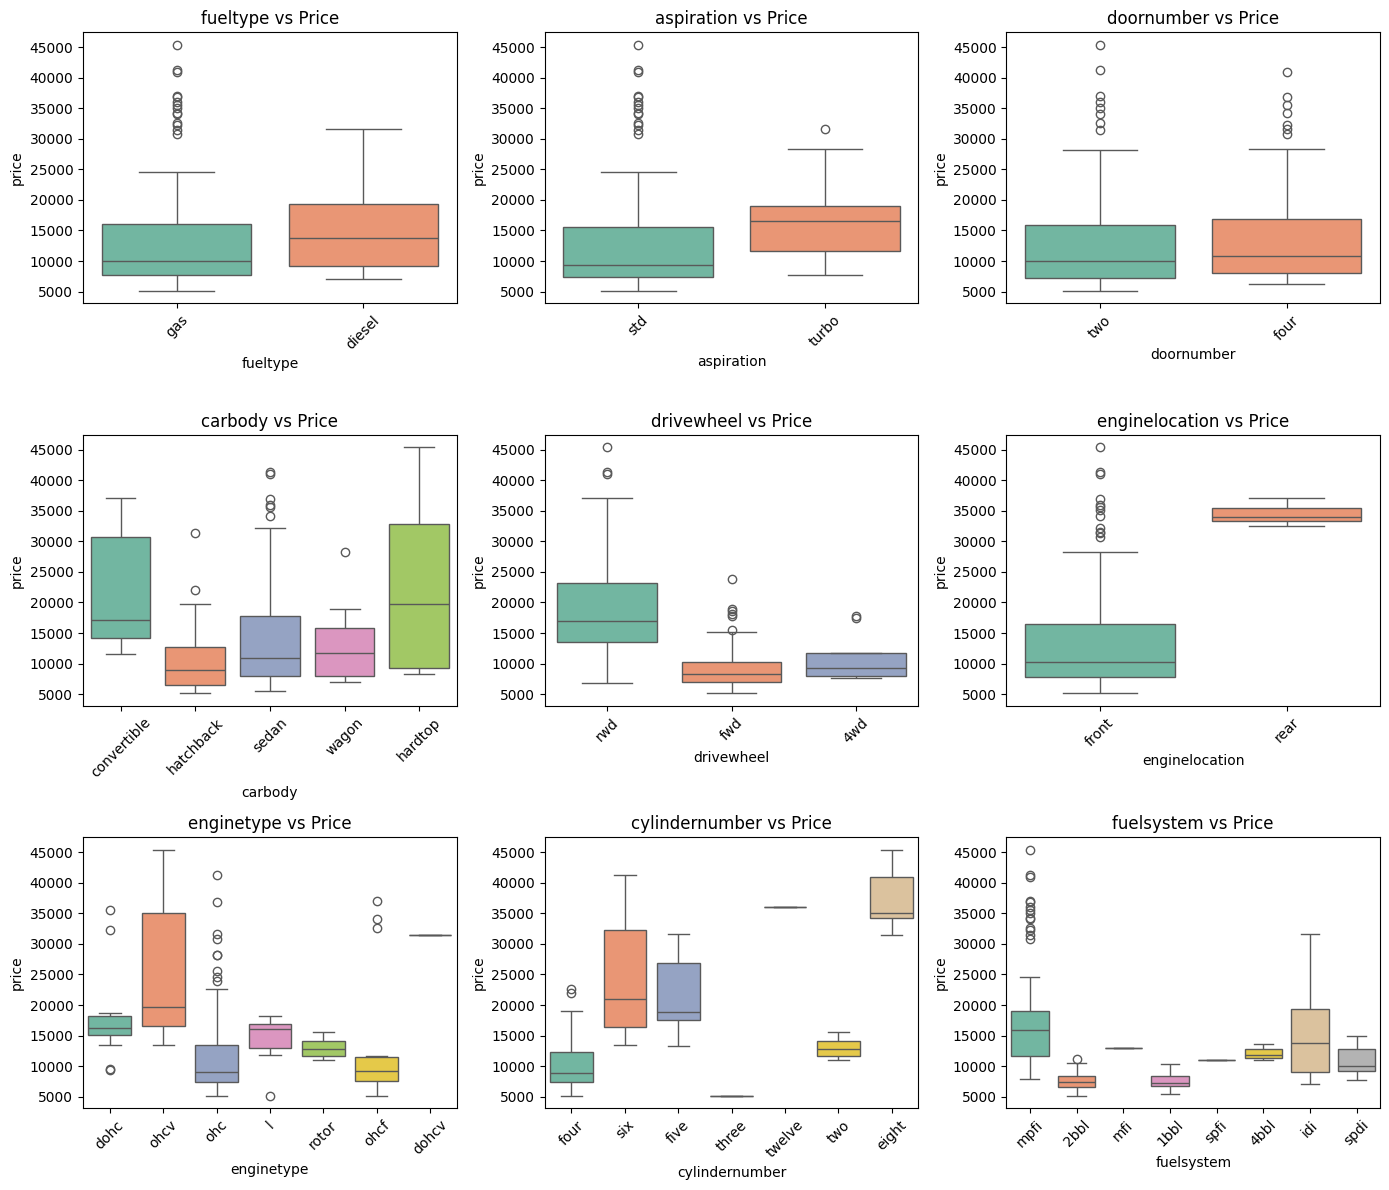

In [25]:
#Categorical Feature vs. Price

plt.figure(figsize=(14, 12))
for idx, feature in enumerate(categorical_columns):
    plt.subplot(3, 3, idx + 1)
    sns.boxplot(data=df, x=feature, y='price', palette='Set2')
    plt.title(f'{feature} vs Price')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

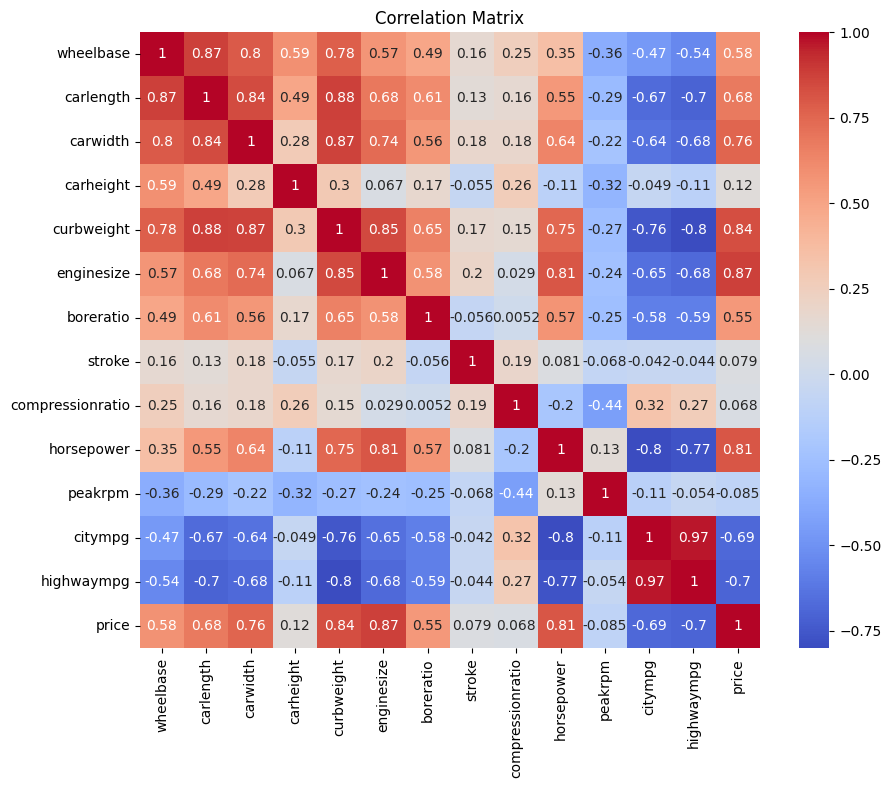

In [26]:
#Correlation Analysis
correlation_matrix = df[numerical_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**4. Data Pre-Processing**

In [27]:
df['brand'] = df['CarName'].apply(lambda x: x.split(' ')[0])
df['model'] = df['CarName'].apply(lambda x: ' '.join(x.split(' ')[1:]))

# Define categorical and numerical columns
categorical_columns = ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel',
                       'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'brand', 'model']
numerical_columns = ['wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight',
                     'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower',
                     'peakrpm', 'citympg', 'highwaympg']

# Encode categorical variables
LabelEncoder = LabelEncoder()
for col in categorical_columns:
    df[col] = LabelEncoder.fit_transform(df[col])


# Feature Engineering
df['power_to_weight_ratio'] = df['horsepower'] / df['curbweight']
for col in numerical_columns:
    df[f'{col}_squared'] = df[col] ** 2
df['log_enginesize'] = np.log(df['enginesize'] + 1)  # Adding 1 to avoid log(0)

#Feature Scaling
scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

**5. Train the Model**

In [28]:
X = df.drop(['price', 'CarName'], axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [29]:
mse = mean_squared_error(y_test, y_pred)
r2_score = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2_score}')

Mean Squared Error: 10928450.668414652
R^2 Score: 0.8615670883413198


In [30]:
pred_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Difference': y_test - y_pred})
pred_df

,Actual,Predicted,Difference
15,30760.000,24644.498946,6115.501054
9,17859.167,19770.234284,-1911.067284
100,9549.000,8323.732428,1225.267572
132,11850.000,13885.801565,-2035.801565
68,28248.000,26718.615839,1529.384161
95,7799.000,7079.308256,719.691744
159,7788.000,10106.850946,-2318.850946
162,9258.000,6570.571035,2687.428965
147,10198.000,10418.264330,-220.264330
182,7775.000,10904.998472,-3129.998472
